## Download ALL sectors or chosen ones (Anakin noooo)

In [ ]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = "ALL"
flux_column = "pdcsap_flux"

download.download(INPUT, OUTDIR, SECTOR, flux_column=flux_column)

Lets download just one sector

In [ ]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = 100

download.download(INPUT, OUTDIR, SECTOR)

Or we can just select `sap_flux` instead of `pdcsap_flux`.


In [ ]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = "ALL"
flux_column = "sap_flux"

download.download(INPUT, OUTDIR, SECTOR, flux_column=flux_column)

We can plot all downloaded 5 sectors

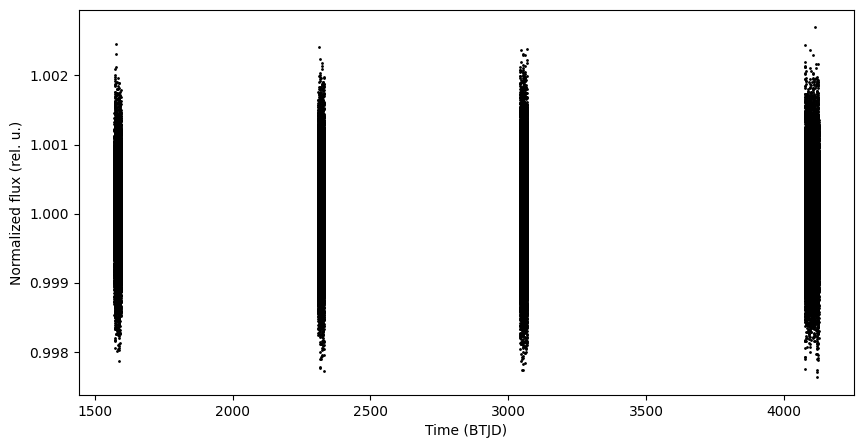

In [48]:
import numpy as np
import matplotlib.pyplot as plt

time, flux, flux_err = np.loadtxt('lightcurves/TIC144219989_SPOC_PDCSAP.txt', unpack=True)

plt.subplots(figsize=(10, 5))
plt.plot(time, flux, marker='.', linestyle='none', color='black', markersize=2)
plt.xlabel('Time (BTJD)')
plt.ylabel('Normalized flux (rel. u.)')
plt.show()


But lets zoom, so we actually see the pulsations

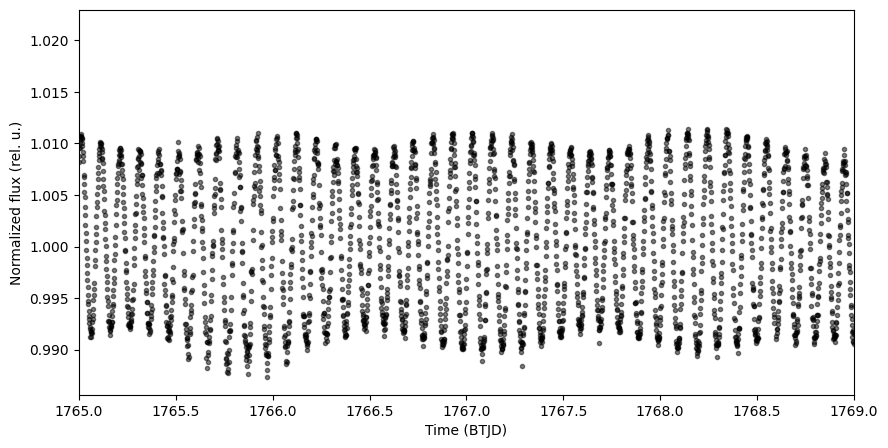

In [53]:
import numpy as np
import matplotlib.pyplot as plt

time, flux, flux_err = np.loadtxt('lightcurves/TIC396298498_SPOC.txt', unpack=True)

plt.subplots(figsize=(10, 5))
plt.plot(time, flux, marker='.', linestyle='none', color='black', alpha=0.5)
plt.xlabel('Time (BTJD)')
plt.ylabel('Normalized flux (rel. u.)')
plt.xlim(1765,1769)
plt.show()

## Plotting and comapring periodograms

We use the lomb-scargle, be aware of the amplitude being size (ppm) 1e6

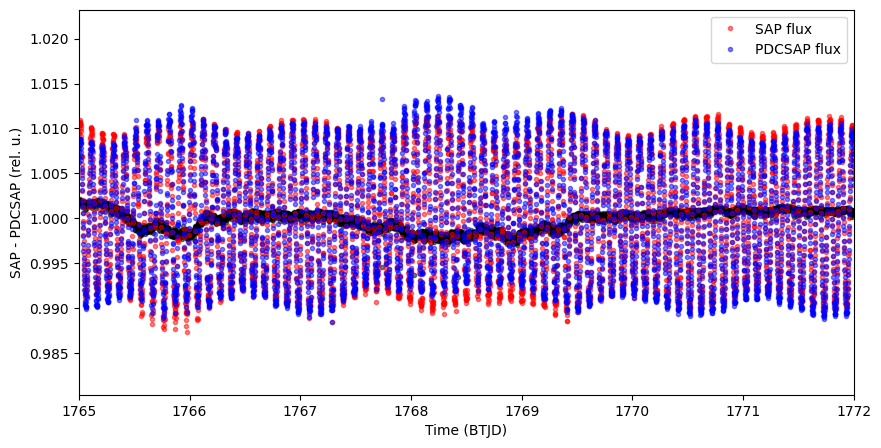

In [52]:
import numpy as np
import matplotlib.pyplot as plt

time1, flux1, flux_err1 = np.loadtxt('lightcurves/TIC396298498_SPOC_SAP.txt', unpack=True)
time2, flux2, flux_err2 = np.loadtxt('lightcurves/TIC396298498_SPOC_PDCSAP.txt', unpack=True)

# Keep only time points present in BOTH light curves
time_common, i1, i2 = np.intersect1d(time1, time2, return_indices=True)
flux1_common = flux1[i1]
flux2_common = flux2[i2]

plt.subplots(figsize=(10, 5))

plt.plot(time_common,flux1_common - flux2_common +1,
         marker='.',
         linestyle='none',
         color='black',alpha=0.5)

plt.plot(time1, flux1, marker='.', linestyle='none', color='red', alpha=0.5, label='SAP flux')
plt.plot(time2, flux2, marker='.', linestyle='none', color='blue', alpha=0.5, label='PDCSAP flux')


plt.xlabel('Time (BTJD)')
plt.ylabel('SAP - PDCSAP (rel. u.)')
plt.xlim(1765,1772)
plt.legend()


plt.show()

We can plot the difference between `sap_flux` and `pdcsap_flux`.

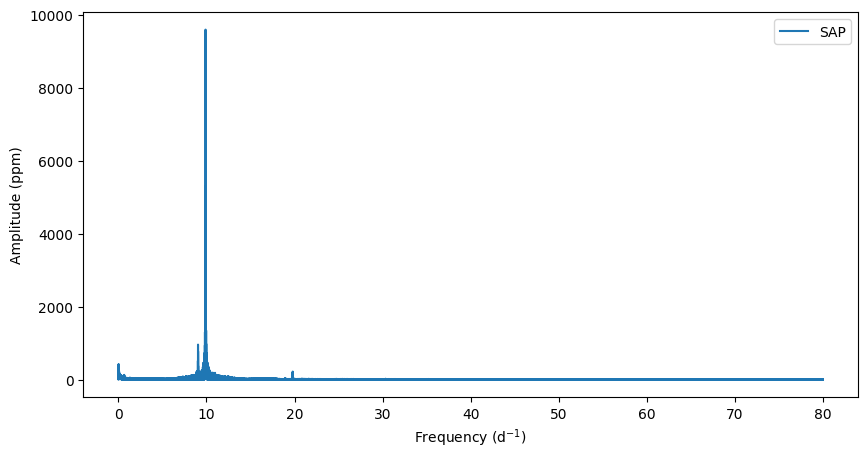

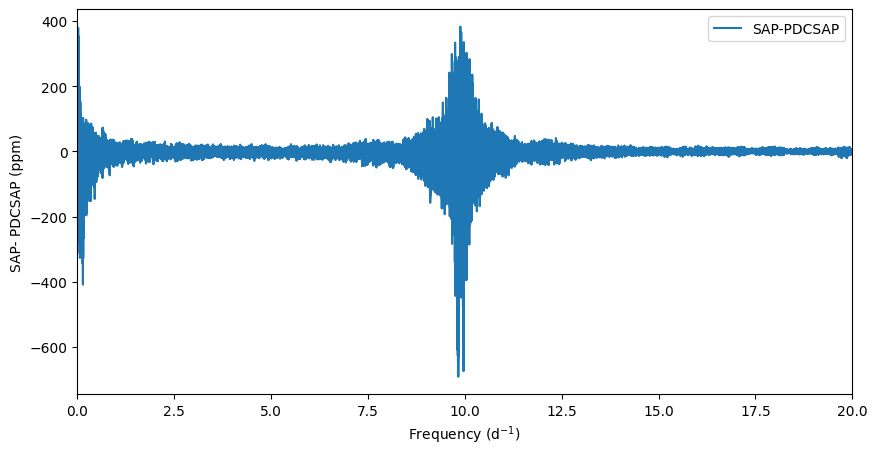

In [15]:
import lightkurve as lk
import matplotlib.pyplot as plt

pg1 = lk.LightCurve(time=time1, flux=flux1).to_periodogram(
    method="lombscargle",
    #normalization="amplitude",
    minimum_frequency=0,
    maximum_frequency=80,
)

pg2 = lk.LightCurve(time=time2, flux=flux2).to_periodogram(
    method="lombscargle",
    #normalization="amplitude",
    minimum_frequency=0,
    maximum_frequency=80,
)

plt.figure(figsize=(10, 5))

plt.plot(pg1.frequency.value, pg1.power.value * 1e6, label="SAP")
plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("Amplitude (ppm)")
plt.legend()

plt.show()

plt.figure(figsize=(10, 5))

plt.plot(pg1.frequency.value, (pg1.power.value - pg2.power.value) * 1e6, label="SAP-PDCSAP")
plt.xlim(0,20)
plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("SAP- PDCSAP (ppm)")
plt.legend()

plt.show()

In [2]:
import importlib
import prewhitten

importlib.reload(prewhitten)

prewhitten.prewhitten(
    INPUT_DIR="lightcurves/TIC396298498_SPOC_SAP.txt",
    OUTDIR="periodograms",
    SNR_LIMIT=4.0,
    MAX_FREQS=50,
    MAX_FREQUENCY=80
)

INPUT: lightcurves/TIC396298498_SPOC_SAP.txt
FILES: ['lightcurves/TIC396298498_SPOC_SAP.txt']
1 light curves
   1 TIC396298498_SPOC_SAP: 10 freqs, baseline 1871 d, 21 s

Finished


In [6]:
import os
import glob

FILE = "lightcurves/TIC396298498_SPOC_PDCSAP.txt"

print("Current directory:", os.getcwd())
print("File exists:", os.path.exists(FILE))
print("Files in lightcurves:")
print(glob.glob("lightcurves/*.txt")[:20])

Current directory: /Users/michalzummer/Documents/DeltaSct/TESS/TEST11/TESTgit
File exists: True
Files in lightcurves:
['lightcurves/TIC396298498_SPOC_PDCSAP.txt', 'lightcurves/TIC407514449_SPOC_PDCSAP.txt', 'lightcurves/TIC407514449_SPOC_SAP.txt', 'lightcurves/TIC396298498_SPOC.txt', 'lightcurves/TIC407514449_SPOC.txt', 'lightcurves/TIC396298498_SPOC_SAP.txt']


In [7]:
import os

print(os.path.exists(
    "periodograms/TIC396298498_SPOC_PDCSAP_frequencies.txt"
))

False


In [1]:
import importlib
import prewhitten

importlib.reload(prewhitten)

prewhitten.prewhitten(
    INPUT_DIR="lightcurves/TIC396298498_SPOC_PDCSAP.txt",
    OUTDIR="periodograms"
)

INPUT: lightcurves/TIC396298498_SPOC_PDCSAP.txt
FILES: ['lightcurves/TIC396298498_SPOC_PDCSAP.txt']
1 light curves
   1 TIC396298498_SPOC_PDCSAP: 8 freqs, baseline 1871 d, 15 s

Finished


frequency_d-1	amplitude_ppm	noise_ppm	SNR
0.02018366	404.891	83.361	4.62
0.05655214	431.324	75.562	5.73
0.06397343	457.604	87.873	4.66
0.09540870	464.128	80.265	5.00
0.14556374	435.166	84.746	5.89
0.16139701	321.571	66.734	4.82
9.04371758	967.675	6.787	142.61
9.89710334	9666.924	9.922	973.80

frequency_d-1	amplitude_ppm	noise_ppm	SNR
0.02018366	404.891	83.361	4.62
0.05655214	431.324	75.562	5.73
0.06397343	457.604	87.873	4.66
0.09540870	464.128	80.265	5.00
0.14556374	435.166	84.746	5.89
0.16139701	321.571	66.734	4.82
9.04371758	967.675	6.787	142.61
9.89710334	9666.924	9.922	973.80



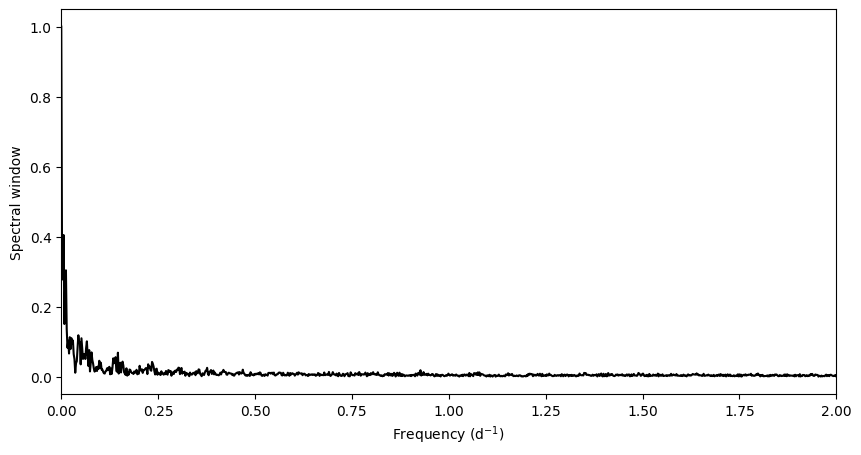

In [22]:
import numpy as np
import matplotlib.pyplot as plt

frequency = np.linspace(0, 2, 1000)

window = np.zeros(len(frequency))

for i, f in enumerate(frequency):
    window[i] = np.abs(np.sum(np.exp(-2j * np.pi * f * time1)))

window /= len(time1)

plt.figure(figsize=(10, 5))

plt.plot(frequency, window, color="black")

plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("Spectral window")

plt.xlim(0, 2)

plt.show()

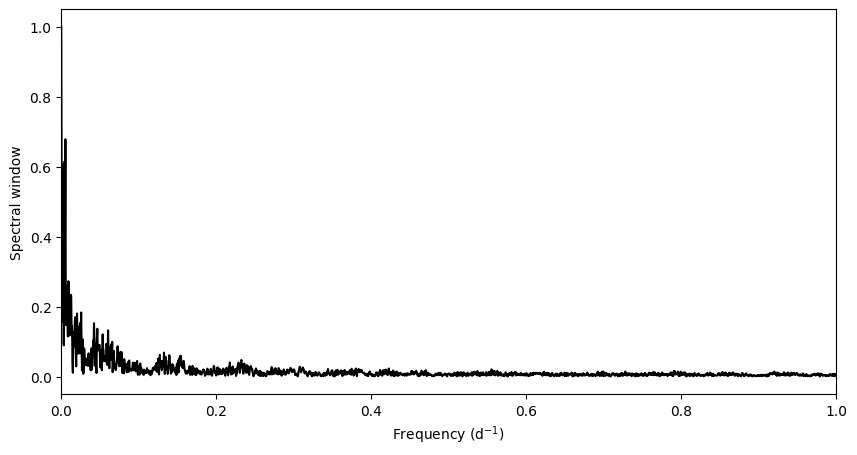

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# median cadence
dt = np.median(np.diff(np.sort(time1)))

# regular time grid covering the observations
tgrid = np.arange(time1.min(), time1.max() + dt, dt)

# sampling mask: 1 = observation exists, 0 = gap
window = np.zeros(len(tgrid))

indices = np.round((time1 - time1.min()) / dt).astype(int)
indices = indices[(indices >= 0) & (indices < len(window))]

window[indices] = 1

# FFT of sampling function
spec_window = np.abs(np.fft.rfft(window))
frequency = np.fft.rfftfreq(len(window), d=dt)

# normalize central peak to 1
spec_window /= spec_window[0]

# only frequencies you want
mask = frequency <= 80

plt.figure(figsize=(10, 5))

plt.plot(frequency[mask], spec_window[mask], color="black")

plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("Spectral window")

plt.xlim(0, 1)

plt.show()

## Another TIC

All sectors

In [39]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = "ALL"
flux_column = "pdcsap_flux"

download.download(INPUT, OUTDIR, SECTOR, flux_column=flux_column)

1 targets
Sector: ALL
   1 TIC 144219989: 5 sectors, 82406 pts, baseline 2554.2 d -> TIC144219989_SPOC_PDCSAP.txt

Finished


One sector

In [40]:
import download

INPUT = "tic.txt"
OUTDIR = "lightcurves"
SECTOR = 100

download.download(INPUT, OUTDIR, SECTOR)

1 targets
Sector: 100
   1 TIC 144219989: 1 sectors, 16531 pts, baseline 25.4 d -> TIC144219989_S100_SPOC_PDCSAP.txt

Finished


We can see that longer baseline means much better resolution, but what about the gaps in the data?

/Users/michalzummer/phoebe_env/lib/python3.13/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))


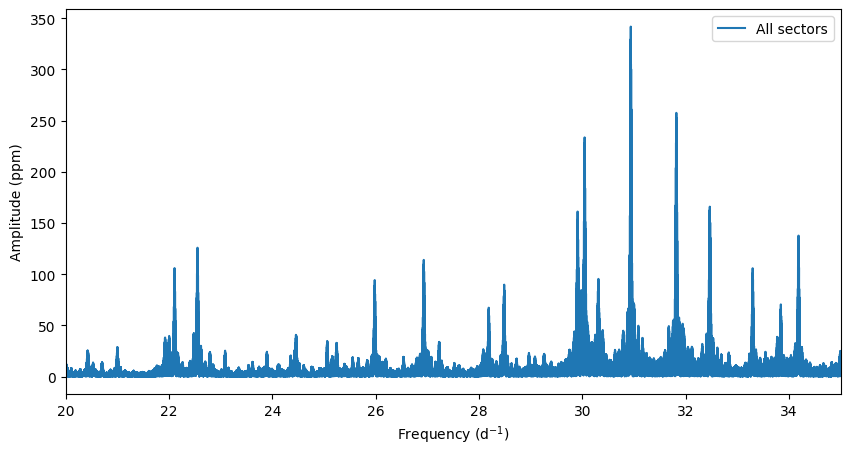

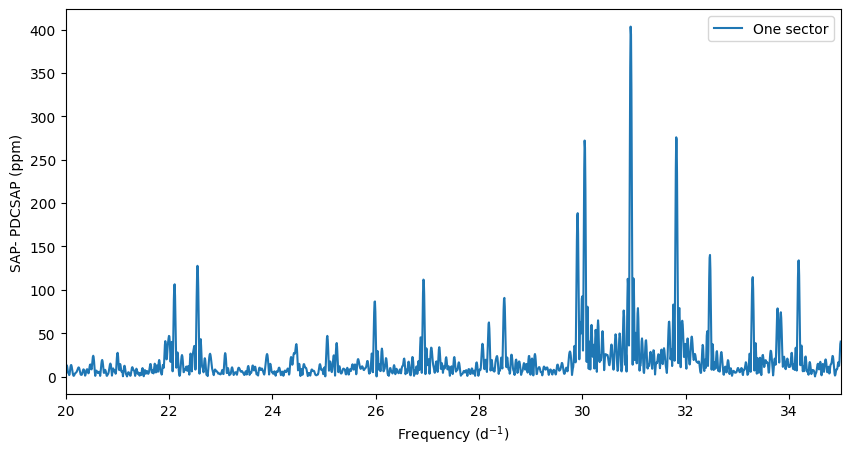

In [54]:
import lightkurve as lk
import matplotlib.pyplot as plt

time1, flux1, flux_err1 = np.loadtxt('lightcurves/TIC144219989_SPOC_PDCSAP.txt', unpack=True)
time2, flux2, flux_err2 = np.loadtxt('lightcurves/TIC144219989_S100_SPOC_PDCSAP.txt', unpack=True)


pg1 = lk.LightCurve(time=time1, flux=flux1).to_periodogram(
    method="lombscargle",
    #normalization="amplitude",
    minimum_frequency=0,
    maximum_frequency=80,
)

pg2 = lk.LightCurve(time=time2, flux=flux2).to_periodogram(
    method="lombscargle",
    #normalization="amplitude",
    minimum_frequency=0,
    maximum_frequency=80,
)

plt.figure(figsize=(10, 5))

plt.plot(pg1.frequency.value, pg1.power.value * 1e6, label="All sectors")
plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("Amplitude (ppm)")
plt.xlim(20, 35)

plt.legend()

plt.show()

plt.figure(figsize=(10, 5))

plt.plot(pg2.frequency.value,  pg2.power.value *1e6, label="One sector")
plt.xlim(20, 35)
plt.xlabel(r"Frequency (d$^{-1}$)")
plt.ylabel("SAP- PDCSAP (ppm)")
plt.legend()

plt.show()

In [45]:
prewhitten.prewhitten(
    INPUT_DIR='lightcurves/TIC144219989_SPOC_PDCSAP.txt',
    OUTDIR="periodograms"
)

INPUT: lightcurves/TIC144219989_SPOC_PDCSAP.txt
FILES: ['lightcurves/TIC144219989_SPOC_PDCSAP.txt']
1 light curves
   1 TIC144219989_SPOC_PDCSAP: 37 freqs, baseline 2554 d, 100 s

Finished


In [47]:
prewhitten.prewhitten(
    INPUT_DIR='lightcurves/TIC144219989_S100_SPOC_PDCSAP.txt',
    OUTDIR="periodograms"
)

INPUT: lightcurves/TIC144219989_S100_SPOC_PDCSAP.txt
FILES: ['lightcurves/TIC144219989_S100_SPOC_PDCSAP.txt']
1 light curves
   1 TIC144219989_S100_SPOC_PDCSAP: 47 freqs, baseline 25 d, 15 s

Finished


## One sector

```text
frequency_d⁻¹   amplitude_ppm   noise_ppm   SNR

3.74278254       61.573          4.329      14.29
17.81087309      41.614          5.742       7.27
18.01614735      53.047          7.634       6.43
18.53119332      59.284          7.358       7.91
18.74633771      45.121          3.463      13.01
19.31929859      43.840          5.752       7.60
19.96487834      47.193          5.670       8.49
21.99852532      44.180          8.098       5.49
22.10702006     103.411         10.445      10.08
22.55283490     125.980         14.016       9.08
24.46274073      42.626          5.753       7.44
25.06359397      45.376          7.460       6.03
25.98130441      92.072          5.533      16.57
26.92902958     111.310          9.350      11.93
28.19025269      69.000          5.086      13.53
28.48910321      97.554         11.082       8.27
29.90703713     169.714         12.995      12.53
30.04635937     243.320         26.791       9.84
30.30910346      64.729         10.406       6.09
30.93768639     400.328          9.142      44.49
31.82020146     273.528         13.739      20.15
31.93548186      60.968          8.131       7.42
32.46864165     143.403          9.030      15.44
33.29634155     112.240         10.243      11.03
33.77472960      73.959          9.352       9.06
33.84289171      59.898          5.189      11.46
34.18524441     137.244         12.117      11.24
35.13696648     219.937         26.328       8.47
35.21971288     114.264          6.502      18.03
35.53459011     157.952         15.993      10.17
36.83091739      77.589          6.603      11.80
37.39190767      87.089          7.097      12.04
37.91913949      66.394         10.591       6.73
38.11719496     144.994         14.856       9.66
38.21130720      49.418          9.408       5.11
39.02598393      50.090          9.659       4.78
39.24592687      41.180          6.486       6.44
39.98448530      40.207          5.343       7.46
40.18639469      43.378          8.717       4.89
41.09760313     123.895         11.082      11.16
41.46028340      61.463          7.785       8.40
41.57504472      53.210          4.169      13.06
43.18098437      35.925          4.620       7.78
44.38556726      47.762         10.724       4.54
46.32285352      95.065          3.625      26.21
46.89935130      38.201          4.066       9.41
47.18656539      43.579          9.062       4.68
```


## Two contiguous sectors

```text
frequency_d⁻¹   amplitude_ppm   noise_ppm   SNR

3.74215144       60.315          3.037      19.90
17.81161560      46.296          4.354      10.40
18.01890923      51.433          5.777       8.73
18.53187064      58.545          5.002      11.23
18.74793540      44.315          2.938      15.17
19.32228397      49.316          4.262      11.84
19.96403543      51.885          4.425      11.94
22.00212381      45.022          5.403       8.34
22.10752089     105.740          6.563      15.92
22.55204313     127.433          9.447      13.48
24.45978110      46.513          5.251       8.83
25.06249852      44.420          5.196       8.60
25.98163198      96.015          4.133      22.89
26.93082675     108.012          6.911      15.62
28.18896076      73.663          3.757      19.70
28.48802877      93.905          7.818      11.55
29.90868774     164.527          8.770      18.39
30.00578890      52.943          4.876      10.86
30.04448428     248.024         16.886      14.44
30.31229585      57.834          7.146       8.17
30.93785729     406.680          6.957      58.44
31.82028494     273.596          9.575      28.35
31.93907983      59.923          5.953       9.93
32.46721621     145.539          6.389      22.03
33.29682137     110.731          7.027      16.31
33.77158823      64.579          6.976      10.75
33.84247316      62.988          4.198      14.90
34.18492264     139.551          7.789      17.91
35.13649561     222.117         15.980      14.24
35.21918864     112.183          4.639      24.08
35.53177137     148.052         10.360      14.75
36.82853988      75.105          4.625      16.34
37.39151469      86.549          4.701      17.91
37.91039618      63.004          7.200       8.90
38.11834094     140.840          9.859      14.36
39.02727007      47.226          4.877       9.67
39.24688416      46.817          6.381       6.83
39.98357508      37.958          3.584      10.59
40.18581225      43.514          5.585       7.80
41.09735011     120.812          8.383      14.31
41.46172485      63.038          6.130      10.38
41.57199451      58.398          3.565      16.43
43.18313198      38.638          3.371      11.43
44.01949470      44.965          7.310       6.11
44.38902005      40.504          7.356       5.52
46.32256872      95.940          2.668      35.73
47.18422094      45.450          6.622       6.92
```


## All sectors

```text
frequency_d⁻¹   amplitude_ppm   noise_ppm   SNR

3.74254012       58.329          1.912      30.49
18.01707550      50.973          3.398      15.07
18.53136973      60.636          3.411      17.98
19.31938740      45.649          2.687      16.99
19.96733273      46.536          3.077      15.19
22.10488861     100.153          5.602      17.85
22.55472659     121.391          6.760      18.04
25.97894920      90.597          3.544      25.42
26.93089402     114.835          3.954      29.22
28.18855291      70.910          2.435      29.21
28.48814776      87.839          4.610      18.77
29.90855214     176.704          7.227      24.14
30.00282561      50.002          4.767      10.56
30.04445547     244.797         12.832      18.51
30.30898579      97.129          6.052      16.26
30.39799090      45.823          4.156      11.02
30.93782885     345.344          6.073      56.83
31.82005805     267.967          6.356      41.55
31.93877404      51.316          4.742      10.83
32.46731407     174.888          4.847      35.79
33.29688926     105.227          4.061      25.89
33.84213220      69.216          3.530      19.52
34.18476585     137.702          4.621      29.78
35.13933698     264.068         12.268      19.63
35.14371760      72.283          5.142      14.05
35.21910193     109.714          6.279      17.32
35.53143680     156.791          9.150      17.79
36.82866130      67.698          2.805      24.17
37.39148368      84.023          3.295      25.47
37.90841090      50.684          5.169       9.80
38.11812293     149.947          6.145      24.49
41.09778553     194.153          6.591      28.78
41.10025996      81.345          5.093      15.71
43.18660617      71.066          3.104      22.66
44.01595028      50.332          4.893      10.30
46.32266647      88.427          1.851      47.62
47.18098495      48.465          4.259      11.38
```

# TIC 144219989 Frequency Summary

| Dataset | TIC | Sector(s) | Dominant frequency (d⁻¹) | Dominant amplitude (ppm) | Amplitude-weighted frequency (d⁻¹) | Power-weighted frequency (d⁻¹) | Mean amplitude (ppm) | Total power (ppm²) | Number of frequencies | ν_low (d⁻¹) | ν_high (d⁻¹) | Envelope width (d⁻¹) | α |
|---|---:|:---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| All sectors | 144219989 | All | 30.93782885 | 345.344 | 32.182961 | 32.476455 | 110.891 | 647466.550 | 37 | 3.74254012 | 47.18098495 | 43.43844483 | 0.154729 |
| Sector 100 | 144219989 | 100 | 30.93768639 | 400.328 | 31.978716 | 31.933246 | 93.917 | 651109.612 | 47 | 3.74278254 | 47.18656539 | 43.44378285 | 0.149942 |
| Sectors 100–101 | 144219989 | 100–101 | 30.93785729 | 406.680 | 31.818300 | 31.832776 | 94.061 | 654216.732 | 47 | 3.74215144 | 47.18422094 | 43.44206950 | 0.146289 |

### Source files

- **All sectors:** `TIC144219989_SPOC_PDCSAP_frequencies.txt`
- **Sector 100:** `TIC144219989_S100_SPOC_PDCSAP_frequencies.txt`
- **Sectors 100–101:** `TIC144219989_S100and101_SPOC_PDCSAP_frequencies.txt`